**Lab 4: FIR filters and envelopes**

The goal of this lab is to learn how to implement FIR filters in Python, and how we can use them to improve our synthesis.

In [15]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

**1. Overview of Filtering**

For this lab, we will define an FIR filter as a discrete-time system that converts an input signal $x[n]$ into an output signal $y[n]$ by means of the weighted summation:

$$
y[n] = \sum_{k=0}^M b_kx[n-k]
$$

The function *np.convolve()* is a generic function with which to implement FIR filters. The following code implements a three-point averaging system:

In [16]:
fs = 1
x = [np.floor(x/10) for x in range(50)]
b = np.array([1.0/3, 1.0/3, 1.0/3])
y = np.convolve(b, x)

plot_signals([x, y], fs, name=['input x[n]', 'output y[n]'], mode='lines+markers')

1.1 Explain the filtering action of the 5-point averager by comparing the plot of the input $x[n]$ and the output $y[n]$. This filter might be called a “smoothing” filter. Note how the transitions from one level to another have been “smoothed.”

The 5-point averager, is used to smooth or average a signal. It operates by averaging the current sample and four previous samples from the input signal to create a smoother output. This filtering action reduces the impact of high-frequency noise and sharp transitions in the input. We can see this from the example above by noteching how the transitions last longer and have less of an angle of attack. It's an overall smoother graphic than the blue one.

*1.2* Define a function `averaging_filter(x, N)` which implements the N-points averaging filter using the `np.convolve` function.

In [17]:
import numpy as np

def averaging_filter(x, N):
    """
    Applies a N-point averaging filter to the input signal x

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the filter
    """

    # Write your code here

    b = np.ones(N) / N

    y = np.convolve(x, b, mode='full')

    return y




1.3 Run the example above using the `averaging_filter` instead. Change the number N to different values and explain what happen.

In [18]:
# Write your code here

N_values = [3, 5, 10, 20]

for N in N_values:
    y = averaging_filter(x, N)
    plot_signals([x, y], fs, name=[f'Input x[n]', f'Output y[n] (N={N})'], mode='lines+markers')

1.4 How would you classify this filter, as a low-pass o high-pass filter?

[Double click to write your answer]
it smooths the signal by averaging a range of samples, which effectively reduces the impact of high-frequency noise or rapid changes in the signal. This behavior makes it a low-pass filter, as it passes the lower-frequency components and attenuates the higher-frequency components, resulting in a smoother signal.







---

**2. Envelope detector**

Now we'll implement an envelope detector by concatenating two systems: a full-wave rectifier (absolute value) and the N-point averaging filter.

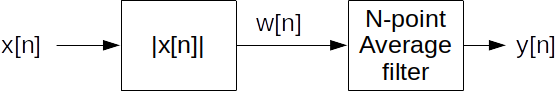

2.1 Define a function `envelope(x, N)` which applies an N-point averaging filter to the full-wave rectified signal and returns the output $y[n]$.

**Note 1**: to calculate the full-wave rectified signal check the `np.abs()` function.

**Note 2**: The output should have the same length as the input signal. Use 'same' mode (see [np.convolve](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html) documentation).

In [19]:
import numpy as np

def envelope(x, N):
    """
    Extracts the envelope of the input signal x by concatenating a full-wave rectifier and an N-point averaging filter.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e., the envelope of the signal x.
    """
    # write your code here
    w = np.abs(x)

    b = np.ones(N) / N
    y = np.convolve(w, b, mode='same')

    return y


2.2 Load your reference signal and calculate its envelope using the function you designed. Plot the reference signal and envelope in the same figure.

In [20]:

x_ref, fs_ref = load_audio("audio/audio.wav") 
N = 50
y_env = envelope(x_ref, N)

plot_signals(
    [x_ref, y_env], 
    fs_ref, 
    name=['Reference Signal $x[n]$', f'Envelope $y[n]$ (N={N})'], 
    mode='lines'
)

2.3 Change the number N to get a good result. What happens when you change the number N?

The number N changes how many samples takes to do the average for the envelope. Changing the N to a smaller number, the envelope follows closer to the audio, and it's less smoother and has more detail. Changing the N to a big number, makes the envelope more smoother, and has less detail.

2.4 Explain with your own words why this system achieves extracting the envelope. It might be useful to plot together the signals $x[n]$, $w[n]$ and $y[n]$.

The system extracts the envelope, by taking the absolute value of the signal, obtaining their amplitude, and we do the average filter, that makes it more smoother. After removing the fast oscillations and keeping the slow changes, we obtain the envelope.

In [21]:
plot_signals([x_ref, np.abs(x_ref),y_env], fs, name=['x[n]', 'n rectified', 'y[n]'])

2.5 Now let's apply this envelope to the synthesized signal. Copy the code from Lab3 Ex. 2.1 and generate the synthesized signal. Then multiply the synthesized signal by the envelope. Note that both signal and envelope should have the same length. You can define a time vector of the same length of the envelope to create the signal:

In [22]:
fs = 44100
f0 = 174.614
weights = [0.7150, 0.7367, 0.4176, 0.2959, 1, 0.4945, 0.5297, 0.1423, 0.2304, 0.3306]

def synthesize(f0, phi, Ak, t):
    y = 0
    for k in range(1, len(Ak) + 1):
        y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
    return y

t = np.arange(len(y_env)) / fs

y_synth = synthesize(f0, -np.pi/3, weights, t)

y_synth_env = y_synth * y_env

plot_signals([y_synth_env, y_env], fs, name=["Synth envelope", "Envelope"])


2.6. Compare the spectrograms of the reference signal and the synthesized signal. What are the main differences?

In [23]:

# Write your code here
from scipy.signal import spectrogram
window_length = 8106
# Reference signal
print(x_ref, fs_ref)
ff_ref, tt_ref, S_ref = spectrogram(x_ref, fs_ref, noverlap=window_length/2)
plot_spectrogram(ff_ref, tt_ref, S_ref)





[ 0.001376    0.00204739 -0.00011936 ...  0.00482449  0.00500759
  0.00549587] 44100


ValueError: noverlap must be less than nperseg.

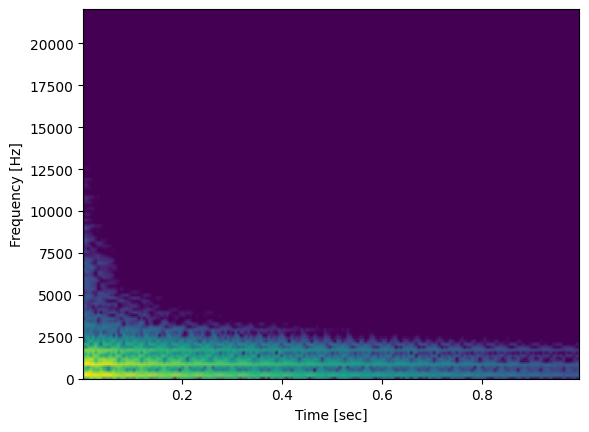

In [ ]:
# Synthesized signal
ff_syn, tt_syn, S_syn = spectrogram(y_synth_env, fs)
plot_spectrogram(ff_syn, tt_syn, S_syn)


The reference spectogram shows more harmonic richness and higher frequency, with less regular partials and more spread, their high frecuencies decay gradually, and the spectrum looks noisy, and complex.
The synthesized spectogram has fewer partials, all of them perfectly regular and aligned, because it only contains the harmonics that we defined, it shows less energy above the first harmonics, and the spectrum looks cleaner and artificial. The high frequency components disappear earlier in the reference than the synthesized.


2.7 Listen to the synthesized signal and compare it to the reference.



In [ ]:
# Write your code here
from IPython.display import Audio
Audio(x_ref, rate=fs_ref)

In [ ]:
# Write your code here
Audio(y_synth, rate=fs)

In this case, the reference sounds richer and natural, with high-frequency detail and smoother decay.
The synthesized, sounds artificial, simpler, constant, because it only contains a limited number of harmonics, and the decay sounds less complex compared to the reference.